**1. Grid Search Setup for SGD Classifier**

Loads the MNIST dataset, creates a binary classification target (detecting the digit "5"), and sets up a pipeline that scales the data and performs a Grid Search (GridSearchCV) to find the best alpha (regularization strength) and loss hyperparameters.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Load MNIST data
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist['data'], mnist['target'].astype(np.uint8)

# Split into train and test sets
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# Create binary target variables for digit 5
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

# Pipeline: scale -> SGD (fix settings except alpha and loss)
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", SGDClassifier(
        penalty="l2",              # standard L2
        learning_rate="optimal",   # good default
        max_iter=10,
        tol=1e-3,
        random_state=42
    ))
])

# Two-parameter grid on alpha (log scale) and loss
param_grid = {
    "clf__alpha": [1e-6, 3e-6, 1e-5, 3e-5, 1e-4],
    "clf__loss": ["log_loss", "hinge"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

# Use the binary training data
grid.fit(X_train, y_train_5)
print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best params: {'clf__alpha': 1e-05, 'clf__loss': 'hinge'}
Best CV accuracy: 0.9709833333333333


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


**2. Visualize Grid Search Performance & Metrics**

Extracts the grid search cross-validation results into a Pandas DataFrame, visualizes the performance of different loss functions across various alpha values, evaluates the best model on the test set, generates a Confusion Matrix, and prints a classification report.

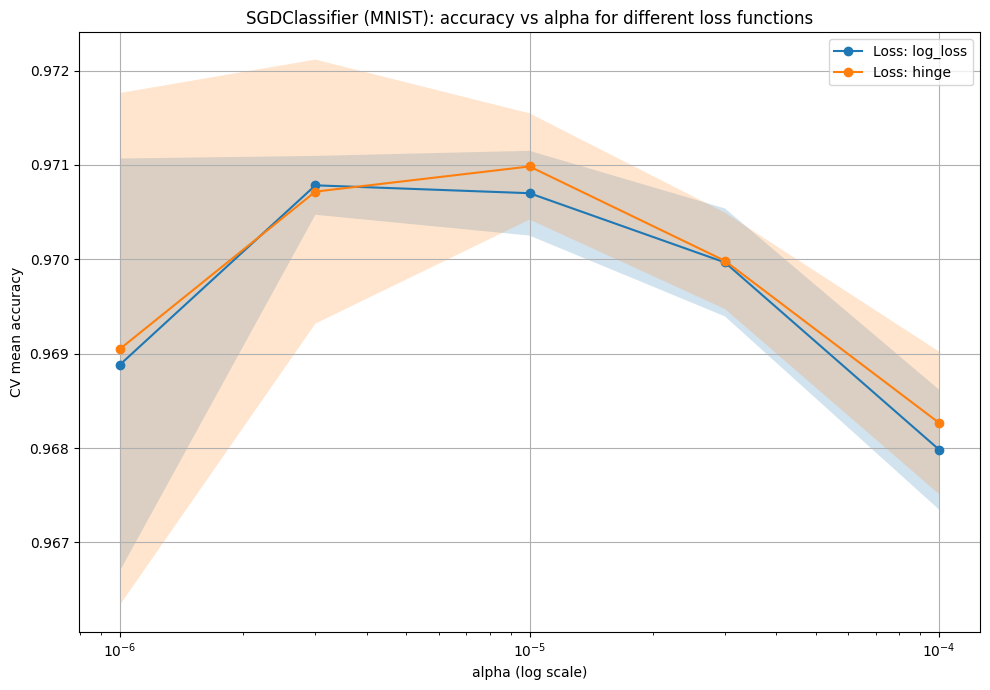

Test accuracy (best model): 0.9727


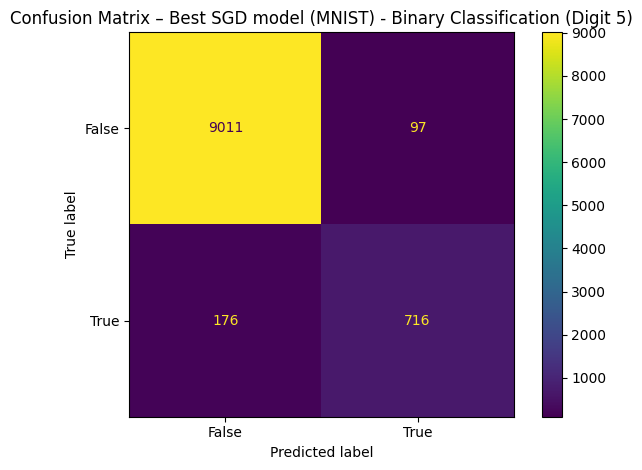

              precision    recall  f1-score   support

       False       0.98      0.99      0.99      9108
        True       0.88      0.80      0.84       892

    accuracy                           0.97     10000
   macro avg       0.93      0.90      0.91     10000
weighted avg       0.97      0.97      0.97     10000



In [4]:
res = pd.DataFrame(grid.cv_results_)
res = res.sort_values("param_clf__alpha")

losses = res["param_clf__loss"].unique()
plt.figure(figsize=(10,7))

for loss_type in losses:
    loss_results = res[res['param_clf__loss'] == loss_type]
    loss_results = loss_results.sort_values("param_clf__alpha")
    alphas = loss_results["param_clf__alpha"].astype(float).values
    mean_scores = loss_results["mean_test_score"].values
    std_scores = loss_results["std_test_score"].values

    plt.plot(alphas, mean_scores, marker="o", label=f'Loss: {loss_type}')
    plt.fill_between(alphas, mean_scores-std_scores, mean_scores+std_scores, alpha=0.2)

plt.xscale("log")
plt.xlabel("alpha (log scale)"), plt.ylabel("CV mean accuracy")
plt.title("SGDClassifier (MNIST): accuracy vs alpha for different loss functions")
plt.grid(True), plt.tight_layout(), plt.legend(), plt.show()

best_model = grid.best_estimator_
sgd_test_acc = best_model.score(X_test, y_test_5) # Use binary test labels for accuracy
print("Test accuracy (best model):", sgd_test_acc)

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test_5, values_format='d') # Use binary test labels for confusion matrix
plt.title("Confusion Matrix – Best SGD model (MNIST) - Binary Classification (Digit 5)")
plt.tight_layout(), plt.show()

y_pred = best_model.predict(X_test)
print(classification_report(y_test_5, y_pred)) # Use binary test labels for classification report

**3. Fine-Tuning with Randomized Search**

Demonstrates an alternative tuning method using RandomizedSearchCV. It samples a fixed number of parameter combinations (n_iter=5) randomly from a specified distribution to save computational time compared to exhaustive grid searching.

In [5]:
from sklearn.model_selection import RandomizedSearchCV

# Pipeline: scale -> SGDClassifier
sgd_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", SGDClassifier(
        max_iter=10,
        tol=1e-3,
        random_state=42
    ))
])

# Small parameter space for quick run
param_distributions = {
    "clf__loss": ["log_loss", "hinge"],       # SVM-style vs logistic regression
    "clf__penalty": ["l2"],
    "clf__alpha": np.logspace(-5, -2, 5)      # small range of regularization strengths
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Randomized search
rnd_search_sgd = RandomizedSearchCV(
    estimator=sgd_pipe,
    param_distributions=param_distributions,
    n_iter=5,                                 # small iterations for quick run
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Use the binary training data
rnd_search_sgd.fit(X_train, y_train_5)
print("SGD best params:", rnd_search_sgd.best_params_)
print("SGD acc (CV):", rnd_search_sgd.best_score_)
best_sgd = rnd_search_sgd.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits
SGD best params: {'clf__penalty': 'l2', 'clf__loss': 'hinge', 'clf__alpha': np.float64(1e-05)}
SGD acc (CV): 0.9709833333333333


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


**4. Classification Model Comparison**

Trains three completely different classification models (Random Forest, Logistic Regression, and Support Vector Classifier) on the same dataset and prints out their test accuracy alongside the previous SGD grid search result for comparison.


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Scale the data for models that require it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate and train RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train_5)

# Evaluate test accuracy of RandomForestClassifier
rf_test_acc = rf_clf.score(X_test, y_test_5)
print(f"RandomForestClassifier Test Accuracy: {rf_test_acc:.4f}")

# Instantiate and train LogisticRegression
log_reg_clf = LogisticRegression(max_iter=200, n_jobs=-1)
log_reg_clf.fit(X_train_scaled, y_train_5)

# Evaluate test accuracy of LogisticRegression
log_reg_test_acc = log_reg_clf.score(X_test_scaled, y_test_5)
print(f"LogisticRegression Test Accuracy: {log_reg_test_acc:.4f}")

# Instantiate and train SVC
svc_clf = SVC(random_state=42)
svc_clf.fit(X_train_scaled, y_train_5)

# Evaluate test accuracy of SVC
svc_test_acc = svc_clf.score(X_test_scaled, y_test_5)
print(f"SVC Test Accuracy: {svc_test_acc:.4f}")

# Display best SGD accuracy from grid search (using global variable sgd_test_acc from earlier cell)
print(f"Best SGD (Grid Search) Test Accuracy: {sgd_test_acc:.4f}")

RandomForestClassifier Test Accuracy: 0.9877
LogisticRegression Test Accuracy: 0.9773
SVC Test Accuracy: 0.9921
Best SGD (Grid Search) Test Accuracy: 0.9727


**5. ROC Curve and AUC Score Verification**

Loops through the trained classifiers, extracts prediction probabilities or decision function scores, calculates True Positive/False Positive rates, and plots a comprehensive ROC curve to evaluate classification quality via AUC scores.

Random Forest AUC: 0.9992
Logistic Regression AUC: 0.9748
SVC AUC: 0.9986
Best SGD (Grid Search) AUC: 0.9557


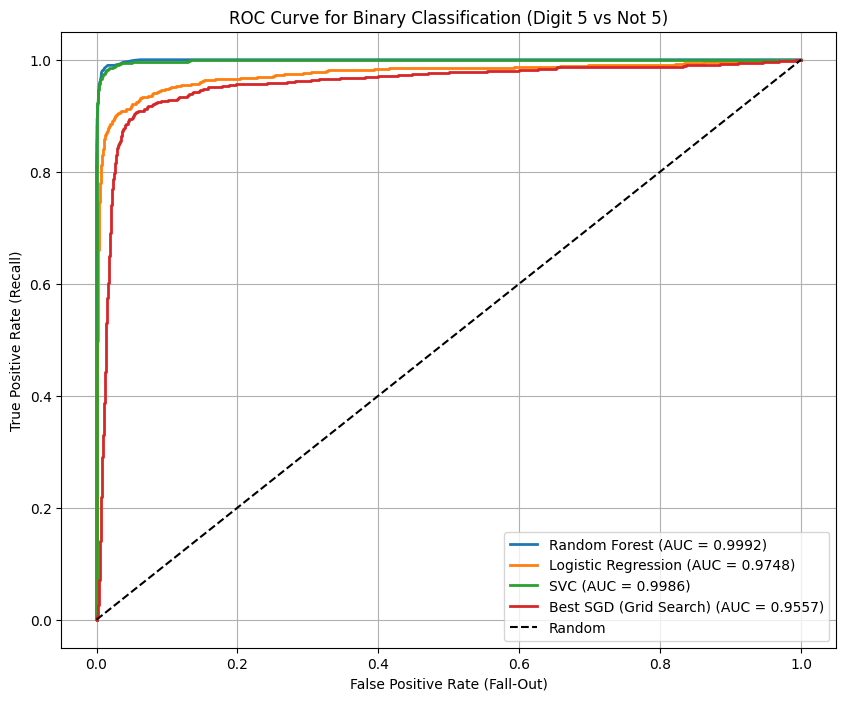

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

# Classifiers for ROC curve
classifiers = [
    ("Random Forest", rf_clf),
    ("Logistic Regression", log_reg_clf),
    ("SVC", svc_clf),
    ("Best SGD (Grid Search)", best_model)
]

# Iterate through classifiers, plot ROC curve and print AUC
for name, clf in classifiers:
    if hasattr(clf, "predict_proba"):
        y_scores = clf.predict_proba(X_test_scaled)[:, 1] if name != "Random Forest" else clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_scores = clf.decision_function(X_test_scaled)
    else:
        continue # Skip if the classifier doesn't have prediction scores

    fpr, tpr, thresholds = roc_curve(y_test_5, y_scores)
    auc = roc_auc_score(y_test_5, y_scores)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')
    print(f"{name} AUC: {auc:.4f}")

plt.plot([0, 1], [0, 1], 'k--', label='Random') # Diagonal random classifier
plt.xlabel("False Positive Rate (Fall-Out)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve for Binary Classification (Digit 5 vs Not 5)")
plt.grid(True)
plt.legend()
plt.show()

**6. California Housing Data Loading & Preprocessing**

Fetches the California Housing regression dataset, splits the features and targets into training and testing subsets ($80/20$ split), and performs standard scaling on the input features.


In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**7. Train Regression Models**

Initializes and trains five unique regression estimators on the scaled housing data: Linear Regression, Ridge, Lasso, a Decision Tree Regressor, and a Random Forest Regressor.


In [2]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Instantiate and train LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Instantiate and train Ridge
ridge_reg = Ridge(random_state=42)
ridge_reg.fit(X_train_scaled, y_train)

# Instantiate and train Lasso
lasso_reg = Lasso(random_state=42)
lasso_reg.fit(X_train_scaled, y_train)

# Instantiate and train DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# Instantiate and train RandomForestRegressor
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

**8. Evaluate Regression Performance & Output Results**

Predicts test outcomes using each trained regression model, computes Mean Squared Error (MSE) and $R^2$ scores, aggregates the metrics into a Python dictionary, transforms it into a clean Pandas DataFrame, and renders a summary histogram of the error scores.

,MSE,R2
Model,,
Linear Regression,0.555892,0.575788
Ridge,0.555855,0.575816
Lasso,1.310696,-0.000219
Decision Tree Regressor,0.495235,0.622076
Random Forest Regressor,0.255368,0.805123


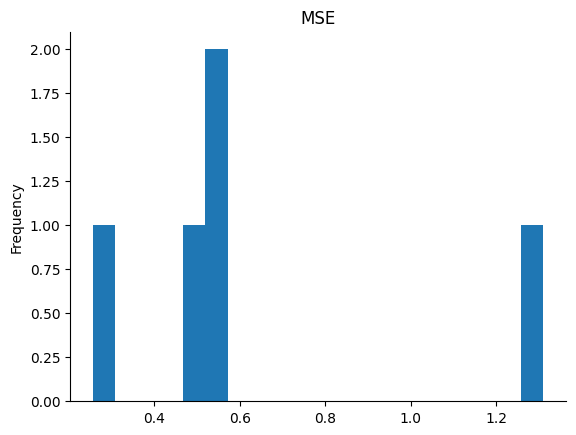

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

model_performance = {}

# Linear Regression
y_pred_lin_reg = lin_reg.predict(X_test_scaled)
mse_lin_reg = mean_squared_error(y_test, y_pred_lin_reg)
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)
model_performance['Linear Regression'] = {'MSE': mse_lin_reg, 'R2': r2_lin_reg}

# Ridge
y_pred_ridge = ridge_reg.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
model_performance['Ridge'] = {'MSE': mse_ridge, 'R2': r2_ridge}

# Lasso
y_pred_lasso = lasso_reg.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
model_performance['Lasso'] = {'MSE': mse_lasso, 'R2': r2_lasso}

# Decision Tree Regressor
y_pred_tree = tree_reg.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
model_performance['Decision Tree Regressor'] = {'MSE': mse_tree, 'R2': r2_tree}

# Random Forest Regressor
y_pred_forest = forest_reg.predict(X_test)
mse_forest = mean_squared_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)
model_performance['Random Forest Regressor'] = {'MSE': mse_forest, 'R2': r2_forest}

# Create DataFrame and display performance
df_performance = pd.DataFrame.from_dict(model_performance, orient='index')
df_performance.index.name = 'Model'
display(df_performance)

# Plot performance metrics
df_performance['MSE'].plot(kind='hist', bins=20, title='MSE')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()